# LangGraph Zero to Hero - Day 2: Messages, Chat Models and Your First LLM Node

Goal of Day 2: learn how a conversation is represented (messages), how a chat model is called, and how to plug an LLM into a graph as a node using MessagesState and the add_messages reducer.

This notebook works with or without an API key. Every example runs out of the box with a built-in fake LLM (free, offline, predictable). When you are ready, change one switch (USE_REAL_LLM = True) to use a real model such as OpenAI, Anthropic, Gemini or a local Ollama model. The graph code does not change.



What you will learn today:

| Part | Topic | You will be able to |
|---|---|---|
| 0 | Recap | Remember the Day 1 building blocks |
| 1 | Setup | Install packages and pick your LLM (fake or real) |
| 2 | Messages | Use HumanMessage, AIMessage, SystemMessage |
| 3 | Chat models | Call a model with invoke() and see that it has no memory |
| 4 | add_messages | Understand the reducer behind every chatbot |
| 5 | MessagesState | Use the ready-made chat state and extend it |
| 6 | First LLM node | Build a chatbot graph |
| 7 | Multi-turn chat | Carry history between calls |
| 8 | System prompts | Give your bot a personality |
| 9 | Mini project | A Study Buddy bot that routes between personas |
| 10 | Cheat sheet | Revise quickly, avoid common mistakes |
| 11 | Exercises | Practice with solutions |

Prerequisite: Day 1 (state, nodes, edges, reducers, conditional edges).

## Part 0 - Day 1 in 30 seconds

```python
class State(TypedDict):                    # 1. State: shared data
    count: int
    log: Annotated[list, operator.add]     #    reducer: HOW updates are merged

def node(state): return {"count": 1}       # 2. Node: returns a PARTIAL update

builder = StateGraph(State)                # 3. Builder
builder.add_node("node", node)
builder.add_edge(START, "node")            # 4. Edges (and conditional edges)
builder.add_edge("node", END)
app = builder.compile()                    # 5. compile, then invoke
```

Today the state will hold a conversation (a list of messages), and one node will call an LLM. An AI agent is basically this plus tools and loops, which we add on Day 3.

## Part 1 - Setup

langgraph already depends on langchain-core, which contains the message classes. We install both to be safe.

To use a real model later, also install one provider package (optional): langchain-openai, langchain-anthropic, langchain-google-genai or langchain-ollama.

In [1]:
%pip install -q -U langgraph langchain-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 18.5 MB/s eta 0:00:00


In [2]:
import sys
from importlib.metadata import version

In [3]:
print("Python         :", sys.version.split()[0])
print("langgraph      :", version("langgraph"))
print("langchain-core :", version("langchain-core"))

Python         : 3.13.15
langgraph      : 1.2.12
langchain-core : 1.6.6


### The LLM switch (fake or real)

- USE_REAL_LLM = False uses fake_llm, a tiny rule-based model that behaves like a chat model: it takes a list of messages and returns an AIMessage.
- USE_REAL_LLM = True uses a real model through LangChain's init_chat_model.

The fake LLM is simple, but it behaves realistically where it matters: it can only answer from the messages you pass in, exactly like a real model. That lets you see why conversation history matters.

In [4]:
import os
from langchain_core.messages import AIMessage
from langchain_core.runnables import RunnableLambda

In [5]:
def find_name(human_texts):
    # look through the user messages for "my name is <name>"
    name = None
    for t in human_texts:
        if "my name is" in t.lower():
            name = t.lower().split("my name is")[1].strip(" .!").title()
    return name

In [6]:
def fake_llm_logic(messages):
    # the persona comes from the system message (if there is one)
    system = next((m.content for m in messages if m.type == "system"), "a helpful assistant")
    human_texts = [m.content for m in messages if m.type == "human"]
    last_user = human_texts[-1]

    if "my name" in last_user.lower() and "?" in last_user:
        name = find_name(human_texts)
        reply = f"Your name is {name}." if name else "Sorry, I do not know your name yet."
    else:
        reply = f"You said: {last_user}"

    return AIMessage(content=f"[{system}] {reply}")

In [7]:
fake_llm = RunnableLambda(fake_llm_logic)

In [8]:
USE_REAL_LLM = False      # set to True after configuring an API key

In [9]:
def get_llm():
    if not USE_REAL_LLM:
        return fake_llm
    from langchain.chat_models import init_chat_model     # pip install langchain
    # Pick ONE and set the matching env var (OPENAI_API_KEY, ANTHROPIC_API_KEY, ...)
    return init_chat_model("openai:gpt-4o-mini")
    # return init_chat_model("anthropic:claude-sonnet-5-5")
    # return init_chat_model("google_genai:gemini-2.0-flash")
    # return init_chat_model("ollama:llama3.1")           # free and local

In [10]:
llm = get_llm()
print("LLM ready:", "REAL model" if USE_REAL_LLM else "FAKE model (offline)")

LLM ready: FAKE model (offline)


## Part 2 - Messages: how conversations are represented

Chat models do not take one string. They take a list of messages, and each message has a role and content.

| Class | Role (.type) | Written by | Typical use |
|---|---|---|---|
| SystemMessage | "system" | You, the developer | Rules and personality, for example "You are a pirate" |
| HumanMessage | "human" | The user | The user's question |
| AIMessage | "ai" | The model | The model's reply |
| ToolMessage | "tool" | A tool (Day 3) | The result of a function call |

The whole list is what the model sees:

```
[ SystemMessage("You are a pirate"),
  HumanMessage("Hi!"),
  AIMessage("Ahoy!"),
  HumanMessage("What is 2+2?") ]
```

In [11]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

In [12]:
sys_msg = SystemMessage(content="You are a friendly tutor.")
user_msg = HumanMessage(content="Explain what a graph is.")
ai_msg = AIMessage(content="A graph is a set of nodes connected by edges.")

In [13]:
for m in (sys_msg, user_msg, ai_msg):
    print(f"{m.type:7s} | {m.content}")

system  | You are a friendly tutor.
human   | Explain what a graph is.
ai      | A graph is a set of nodes connected by edges.


In [14]:
assert sys_msg.type == "system"
assert user_msg.type == "human"
assert ai_msg.type == "ai"
print("Message basics OK")

Message basics OK


Every message has .pretty_print(), which is handy for reading conversations.

In [15]:
for m in (sys_msg, user_msg, ai_msg):
    m.pretty_print()

================================ System Message ================================

You are a friendly tutor.
================================ Human Message =================================

Explain what a graph is.
================================== Ai Message ==================================

A graph is a set of nodes connected by edges.


## Part 3 - Calling a chat model (and why it has no memory)

A chat model is used like this:

```python
reply = llm.invoke(list_of_messages)   # returns an AIMessage
```

Models are stateless. They remember nothing between calls. The only memory is the list of messages you send. Let us prove it.

In [16]:
# Call 1: tell the model our name
r1 = llm.invoke([HumanMessage(content="Hi, my name is asha")])
print("Call 1:", r1.content)

Call 1: [a helpful assistant] You said: Hi, my name is asha


In [17]:
# Call 2: ask for the name, but send ONLY the new question (no history)
r2 = llm.invoke([HumanMessage(content="What is my name?")])
print("Call 2 (no history):", r2.content)

Call 2 (no history): [a helpful assistant] Sorry, I do not know your name yet.


In [18]:
# Call 3: send the history plus the new question
history = [
    HumanMessage(content="Hi, my name is asha"),
    r1,
    HumanMessage(content="What is my name?"),
]
r3 = llm.invoke(history)
print("Call 3 (with history):", r3.content)

Call 3 (with history): [a helpful assistant] Your name is Asha.


In [19]:
assert isinstance(r1, AIMessage)
if not USE_REAL_LLM:
    assert "do not know" in r2.content
    assert "Asha" in r3.content
print("Models are stateless: you supply the history")

Models are stateless: you supply the history


Key insight: a chatbot is a loop that keeps appending messages to a list and sends the whole list to the model every time.

Managing that list by hand gets messy. LangGraph does it for you with state and a reducer.

## Part 4 - add_messages: the reducer behind every chatbot

On Day 1 you used operator.add to append to a list. LangGraph ships a smarter reducer for messages called add_messages. It does four things:

1. Appends new messages to the list.
2. Converts shortcuts like ("user", "hi") into real message objects.
3. Assigns an id to every message.
4. Replaces a message if you send one with the same id, and deletes with RemoveMessage(id=...).

We call it directly first, with no graph, to see how it behaves.

In [20]:
from langgraph.graph.message import add_messages
from langchain_core.messages import RemoveMessage

In [21]:
# 1) append, and convert shortcuts
msgs = add_messages([], [("user", "Hello!"), ("assistant", "Hi there!")])
print([(m.type, m.content) for m in msgs])

[('human', 'Hello!'), ('ai', 'Hi there!')]


In [22]:
assert [m.type for m in msgs] == ["human", "ai"]
assert all(m.id for m in msgs)        # every message got an id

In [23]:
# 2) append another message
msgs = add_messages(msgs, [HumanMessage(content="How are you?")])
print([m.content for m in msgs])
assert len(msgs) == 3

['Hello!', 'Hi there!', 'How are you?']


In [24]:
# 3) replace: same id overwrites the old message
first_id = msgs[0].id
msgs = add_messages(msgs, [HumanMessage(content="Hello (edited)!", id=first_id)])
print([m.content for m in msgs])

['Hello (edited)!', 'Hi there!', 'How are you?']


In [25]:
assert len(msgs) == 3
assert msgs[0].content == "Hello (edited)!"

In [26]:
# 4) delete by id
msgs = add_messages(msgs, [RemoveMessage(id=first_id)])
print([m.content for m in msgs])

['Hi there!', 'How are you?']


In [27]:
assert len(msgs) == 2
assert all(m.id != first_id for m in msgs)
print("add_messages understood")

add_messages understood


Why this matters:

- Appending is the default, so nodes just return new messages, never the whole list.
- Delete and replace let you trim long chats to save tokens.
- Shortcuts like ("user", "hi") keep your code short.

## Part 5 - MessagesState: the ready-made chat state

Instead of writing this every time:

```python
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
```

LangGraph gives you MessagesState, which is exactly the same thing, already built.

In [28]:
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph import StateGraph, START, END, MessagesState

In [29]:
# Option A: write it yourself (to see what is inside)
class MyChatState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [30]:
# Option B: just use the built-in MessagesState (identical behaviour)

# Option C: extend it with your own keys (very common)
class ChatState(MessagesState):
    turn_count: int            # extra key, overwritten each time (no reducer)

In [31]:
print("MyChatState keys:", list(MyChatState.__annotations__))
print("ChatState keys  :", list(ChatState.__annotations__), "(messages is inherited from MessagesState)")

MyChatState keys: ['messages']
ChatState keys  : ['messages', 'turn_count'] (messages is inherited from MessagesState)


## Part 6 - Your first LLM node

```
START -> chatbot -> END
```

The node does three things:

1. It receives the state (all messages so far).
2. It sends all messages to the LLM.
3. It returns the reply as a list: {"messages": [reply]}. The add_messages reducer appends it.

The most common beginner mistake is returning {"messages": reply} (not a list) or returning the whole history again. Always return a list with only the new message(s).

In [32]:
def chatbot(state: MessagesState) -> dict:
    reply = llm.invoke(state["messages"])      # the LLM sees the full history
    return {"messages": [reply]}               # only the NEW message, inside a list

In [33]:
builder = StateGraph(MessagesState)
builder.add_node("chatbot", chatbot)

In [34]:
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

In [35]:
chat_app = builder.compile()

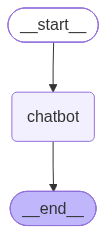

In [36]:
chat_app

In [37]:
result = chat_app.invoke({"messages": [HumanMessage(content="Hello LangGraph!")]})

In [38]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello LangGraph!
================================== Ai Message ==================================

[a helpful assistant] You said: Hello LangGraph!


In [39]:
assert len(result["messages"]) == 2            # 1 human + 1 ai
assert result["messages"][0].type == "human"
assert result["messages"][1].type == "ai"
print("First LLM graph works")

First LLM graph works


### What happened?

1. The input {"messages": [HumanMessage(...)]} became the initial state.
2. chatbot ran, the LLM replied, and the node returned {"messages": [AIMessage]}.
3. add_messages appended the AI reply, so the final state has 2 messages.

### Shortcut inputs

Because of add_messages, you can pass a tuple, a plain dict, or a message object.

In [40]:
r_a = chat_app.invoke({"messages": [("user", "Shortcut with a tuple")]})
print(r_a["messages"][-1].content)

[a helpful assistant] You said: Shortcut with a tuple


In [41]:
r_b = chat_app.invoke({"messages": [{"role": "user", "content": "Shortcut with a dict"}]})
print(r_b["messages"][-1].content)

[a helpful assistant] You said: Shortcut with a dict


In [42]:
r_c = chat_app.invoke({"messages": [HumanMessage(content="Full message object")]})
print(r_c["messages"][-1].content)

[a helpful assistant] You said: Full message object


In [43]:
for r in (r_a, r_b, r_c):
    assert len(r["messages"]) == 2
print("All three input styles work")

All three input styles work


Peek inside a run: stream_mode="updates" shows exactly what the node returned.

In [44]:
for chunk in chat_app.stream({"messages": [("user", "Show me the steps")]}, stream_mode="updates"):
    for node_name, update in chunk.items():
        print(f"node = {node_name!r}")
        for m in update["messages"]:
            print("   returned:", m.type, "|", m.content)

node = 'chatbot'
   returned: ai | [a helpful assistant] You said: Show me the steps


## Part 7 - Multi-turn conversations

Right now every invoke() starts fresh. The graph has no long-term memory yet (that is Day 4, checkpointers). So for now we carry the history ourselves by feeding the previous result back in.

In [45]:
# Without history the bot forgets
r = chat_app.invoke({"messages": [("user", "What is my name?")]})
print("No history:", r["messages"][-1].content)

No history: [a helpful assistant] Sorry, I do not know your name yet.


In [46]:
# With history: pass the previous messages back in each time
history = []
for user_text in ["Hi, my name is Asha", "What is my name?"]:
    result = chat_app.invoke({"messages": history + [HumanMessage(content=user_text)]})
    history = result["messages"]                      # keep the growing list
    print(f"User: {user_text}\nBot : {history[-1].content}\n")

User: Hi, my name is Asha
Bot : [a helpful assistant] You said: Hi, my name is Asha

User: What is my name?
Bot : [a helpful assistant] Your name is Asha.



In [47]:
print("Total messages in history:", len(history))
assert len(history) == 4        # 2 human + 2 ai
if not USE_REAL_LLM:
    assert "Asha" in history[-1].content
print("Multi-turn chat works (manual history for now)")

Total messages in history: 4
Multi-turn chat works (manual history for now)


On Day 4, a checkpointer and a thread_id let LangGraph store this history for you, so you will not need to pass it manually.

## Part 8 - System prompts: give your bot a personality

A SystemMessage tells the model how to behave.

Best practice: do not store it in the state. Add it inside the node, right before calling the LLM. This keeps the saved history clean and lets you change the prompt at any time.

In [48]:
def make_persona_bot(system_prompt: str):
    def bot(state: MessagesState) -> dict:
        messages = [SystemMessage(content=system_prompt)] + state["messages"]   # prepend, do not store
        return {"messages": [llm.invoke(messages)]}

    g = StateGraph(MessagesState)
    g.add_node("bot", bot)
    g.add_edge(START, "bot")
    g.add_edge("bot", END)
    return g.compile()

In [49]:
pirate = make_persona_bot("pirate")
teacher = make_persona_bot("patient teacher")

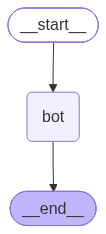

In [50]:
pirate

In [51]:
out_pirate = pirate.invoke({"messages": [("user", "Tell me about graphs")]})
out_teacher = teacher.invoke({"messages": [("user", "Tell me about graphs")]})

In [52]:
print("pirate :", out_pirate["messages"][-1].content)
print("teacher:", out_teacher["messages"][-1].content)

pirate : [pirate] You said: Tell me about graphs
teacher: [patient teacher] You said: Tell me about graphs


In [53]:
for out in (out_pirate, out_teacher):
    assert len(out["messages"]) == 2                       # the system message was NOT stored
    assert all(m.type != "system" for m in out["messages"])
if not USE_REAL_LLM:
    assert "[pirate]" in out_pirate["messages"][-1].content
print("System prompt personas work")

System prompt personas work


Bonus: extra state keys next to messages. We use ChatState from Part 5 to count conversation turns.

In [54]:
def counting_bot(state: ChatState) -> dict:
    reply = llm.invoke(state["messages"])
    turns = state.get("turn_count", 0) + 1
    return {"messages": [reply], "turn_count": turns}

In [55]:
g = StateGraph(ChatState)
g.add_node("counting_bot", counting_bot)
g.add_edge(START, "counting_bot")
g.add_edge("counting_bot", END)

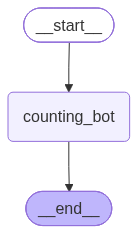

In [56]:
counting_app = g.compile()
counting_app

In [57]:
state = {"messages": [], "turn_count": 0}
for text in ["one", "two", "three"]:
    state = counting_app.invoke({"messages": state["messages"] + [HumanMessage(content=text)],
                                 "turn_count": state["turn_count"]})
print("turn_count =", state["turn_count"], "| messages =", len(state["messages"]))

turn_count = 3 | messages = 6


In [58]:
assert state["turn_count"] == 3
assert len(state["messages"]) == 6
print("Extra keys work alongside messages")

Extra keys work alongside messages


## Part 9 - Mini project: Study Buddy with persona routing

We combine Day 1 (conditional edges) and Day 2 (LLM nodes):

```
START -> detect_mode -> explain_node -> END
                     -> quiz_node    -> END
                     -> summary_node -> END
```

- detect_mode is a rule-based router: "quiz" goes to quiz, "summarize" or "tl;dr" goes to summary, anything else goes to explain.
- Each branch is an LLM node with a different system prompt.
- The state is MessagesState plus a mode key.

In [59]:
from typing import Literal

class StudyState(MessagesState):
    mode: str

In [60]:
PROMPTS = {
    "explain": "Explain simply like a teacher",
    "quiz":    "Ask a short quiz question",
    "summary": "Summarize in one line",
}

In [61]:
def detect_mode(state: StudyState) -> dict:
    last = state["messages"][-1].content.lower()
    if "quiz" in last:
        mode = "quiz"
    elif "summar" in last or "tl;dr" in last:
        mode = "summary"
    else:
        mode = "explain"
    return {"mode": mode}

In [62]:
def route_mode(state: StudyState) -> Literal["explain_node", "quiz_node", "summary_node"]:
    return {"explain": "explain_node", "quiz": "quiz_node", "summary": "summary_node"}[state["mode"]]

In [63]:
def make_llm_node(mode: str):
    def node(state: StudyState) -> dict:
        messages = [SystemMessage(content=PROMPTS[mode])] + state["messages"]
        return {"messages": [llm.invoke(messages)]}
    return node

In [64]:
b = StateGraph(StudyState)
b.add_node("detect_mode", detect_mode)

In [65]:
b.add_node("explain_node", make_llm_node("explain"))
b.add_node("quiz_node", make_llm_node("quiz"))
b.add_node("summary_node", make_llm_node("summary"))

In [66]:
b.add_edge(START, "detect_mode")
b.add_conditional_edges("detect_mode", route_mode)

In [67]:
b.add_edge("explain_node", END)
b.add_edge("quiz_node", END)
b.add_edge("summary_node", END)

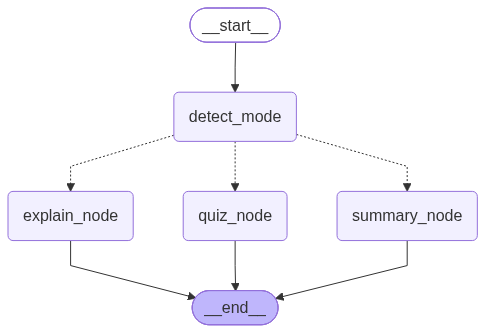

In [68]:
study_app = b.compile()
study_app

In [69]:
cases = {
    "What is a reducer?":              "explain",
    "Quiz me on LangGraph state":      "quiz",
    "Please summarize what a node is": "summary",
}

In [70]:
for question, expected_mode in cases.items():
    out = study_app.invoke({"messages": [HumanMessage(content=question)]})
    print(f"Q: {question}\n   mode = {out['mode']} | A: {out['messages'][-1].content}\n")
    assert out["mode"] == expected_mode
    assert len(out["messages"]) == 2
    if not USE_REAL_LLM:
        assert PROMPTS[expected_mode] in out["messages"][-1].content
print("Study Buddy works")

Q: What is a reducer?
   mode = explain | A: [Explain simply like a teacher] You said: What is a reducer?

Q: Quiz me on LangGraph state
   mode = quiz | A: [Ask a short quiz question] You said: Quiz me on LangGraph state

Q: Please summarize what a node is
   mode = summary | A: [Summarize in one line] You said: Please summarize what a node is

Study Buddy works


In [71]:
print(study_app.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	detect_mode(detect_mode)
	explain_node(explain_node)
	quiz_node(quiz_node)
	summary_node(summary_node)
	__end__([<p>__end__</p>]):::last
	__start__ --> detect_mode;
	detect_mode -.-> explain_node;
	detect_mode -.-> quiz_node;
	detect_mode -.-> summary_node;
	explain_node --> __end__;
	quiz_node --> __end__;
	summary_node --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## Part 10 - Cheat sheet and common mistakes

```python
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, RemoveMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.graph.message import add_messages

llm = ...                                   # any chat model (or fake_llm)

def chatbot(state: MessagesState) -> dict:
    msgs = [SystemMessage("Be concise")] + state["messages"]   # optional system prompt
    return {"messages": [llm.invoke(msgs)]}                    # LIST with the NEW message only

g = StateGraph(MessagesState)
g.add_node("chatbot", chatbot)
g.add_edge(START, "chatbot")
g.add_edge("chatbot", END)
app = g.compile()

app.invoke({"messages": [("user", "Hi")]})
```

Common beginner mistakes:

| Mistake | Fix |
|---|---|
| return {"messages": reply} | Wrap it in a list: {"messages": [reply]} |
| Returning the full history from a node | Return only new messages, the reducer appends them |
| Expecting the model to remember earlier calls | Models are stateless, pass the history (Day 4 automates it) |
| Storing the SystemMessage in state every turn | Prepend it inside the node |
| Calling llm.invoke("text") and expecting chat behaviour | Pass a list of messages |
| Using a real model without an API key | Set the env var (for example OPENAI_API_KEY), or use Ollama or the fake LLM |
| Using a plain list[str] key for messages | Use Annotated[list[AnyMessage], add_messages] or MessagesState |

Setting a real API key (optional):

```python
import os, getpass
os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI key: ")   # never hard-code keys
```

## Part 11 - Exercises (with solutions)

Try each one in a new cell first, then compare.

Exercise 1, two-step bot: build START -> chatbot -> shout -> END. The shout node reads the last AI message and appends a new AIMessage with the same text in upper case.

Exercise 2, prune old messages: write a function that uses RemoveMessage to keep only the last 2 messages of a conversation (use add_messages).

Exercise 3, three-turn chat: using chat_app, hold a 3 turn conversation by feeding the history back each time. After 3 turns you should have 6 messages, and the third question "What is my name?" should be answered correctly.

Solution 1

In [72]:
def shout(state: MessagesState) -> dict:
    last_ai = state["messages"][-1]
    return {"messages": [AIMessage(content=last_ai.content.upper())]}

In [73]:
g = StateGraph(MessagesState)
g.add_node("chatbot", chatbot)
g.add_node("shout", shout)

In [74]:
g.add_edge(START, "chatbot")
g.add_edge("chatbot", "shout")
g.add_edge("shout", END)

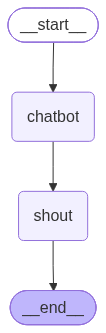

In [75]:
shout_app = g.compile()
shout_app

In [76]:
out = shout_app.invoke({"messages": [("user", "hello")]})
for m in out["messages"]:
    print(m.type, "|", m.content)

human | hello
ai | [a helpful assistant] You said: hello
ai | [A HELPFUL ASSISTANT] YOU SAID: HELLO


In [77]:
assert len(out["messages"]) == 3                       # human, ai, shouted ai
assert out["messages"][-1].content == out["messages"][-2].content.upper()
print("Solution 1 OK")

Solution 1 OK


Solution 2

In [78]:
def keep_last_two(messages):
    to_delete = [RemoveMessage(id=m.id) for m in messages[:-2]]
    return add_messages(messages, to_delete)

In [79]:
conv = add_messages([], [("user", "m1"), ("assistant", "m2"), ("user", "m3"), ("assistant", "m4"), ("user", "m5")])
trimmed = keep_last_two(conv)
print([m.content for m in trimmed])

['m4', 'm5']


In [80]:
assert [m.content for m in trimmed] == ["m4", "m5"]
print("Solution 2 OK")

Solution 2 OK


Solution 3

In [81]:
history = []
for text in ["Hi, my name is Asha", "I love LangGraph", "What is my name?"]:
    res = chat_app.invoke({"messages": history + [HumanMessage(content=text)]})
    history = res["messages"]

In [82]:
print(history[-1].content)

[a helpful assistant] Your name is Asha.


In [83]:
assert len(history) == 6
if not USE_REAL_LLM:
    assert "Asha" in history[-1].content
print("Solution 3 OK")

Solution 3 OK


## Day 2 Summary

You can now:

- Use SystemMessage, HumanMessage and AIMessage, and explain their roles
- Call a chat model with invoke(messages) and explain why it is stateless
- Explain what add_messages does (append, convert, assign ids, replace, remove)
- Use and extend MessagesState
- Build an LLM node and a working chatbot graph
- Carry multi-turn history manually and add system prompt personas
- Combine routing and LLM nodes in a mini project
- Switch between a fake and a real model with one setting

Coming next:

| Day | Topic |
|---|---|
| Day 3 | Tools and tool calling: let the LLM call Python functions and build a ReAct agent from scratch |
| Day 4 | Memory and persistence (checkpointers, thread_id) |
| Day 5 | Human in the loop |
| Day 6 | Parallel branches, sub-graphs, map-reduce |
| Day 7 | Multi-agent systems |
| Day 8 | RAG with LangGraph |
| Day 9 | Streaming, debugging, LangSmith |
| Day 10 | Deployment and capstone |

Homework: add a 4th mode to Study Buddy (for example "translate"), then set USE_REAL_LLM = True with any provider and watch the same graph talk to a real model.